In [1]:
import numpy as np
import matplotlib.pyplot as plt
import QST_core_processes as qst #type: ignore

### Generate data of states and associated measurements probabilities

In [2]:
N = 5000  # number of states
SEED = 14
n_qubits = 2

rhos, taus = qst.generate_dataset_of_states_and_probabilities(N, n_qubits, seed=SEED)
data = {'rhos': rhos, 'taus': taus}

### Setting up Projector Matrix and Simulating Shots

In [3]:
P = qst.build_projector_matrix(n_qubits)
P_noisy = qst.simulate_waveplate_misalignment(np.pi/6, P, n_qubits)

counts = []
n_shots = 100
for rho in data['rhos']:
    p = qst.get_measurement_probs_from_P_and_rho(rho, P_noisy, n_qubits)
    p_noisy = qst.simulate_interference_visibility(p, 0.97)
    counts.append(qst.retrieve_counts_from_n_shots_per_state(p_noisy, n_shots))

data['counts'] = np.stack(counts, axis=0) # easier to work with as a single array
data['P'] = P
data['shots'] = n_shots

In [4]:
qst.add_train_test_split_to_data(data, train_ratio=0.8, seed=SEED)
data_train = qst.get_split(data, "train")
data_test  = qst.get_split(data, "test")

This completes the 'setup' portion

For each set of shots data, must then:
- attempt to reconstruct rho using either stokes or Deep Learning
- (ensure consistency in storage)
- compare resulting density matrices with the actual density matrices stored originally

### Implementing Stokes Reconstruction

In [16]:
outputs = {}
outputs['stokes_rhos'] = qst.stokes_reconstruct_dataset(
    P = data['P'],
    counts = data_test['counts'],
    shots = data['shots'],
    n_qubits = n_qubits
)

In [ ]:
# Naive Neural Network approach
nn_naive = qst.NN_Builder(
    n_qubits=n_qubits,
    model_type="mlp",
    loss_type="mse",
    target="rho",
    hidden_sizes=(256, 256, 256),
    dropout=0.1,
    lr=1e-3,
    batch_size=64,
    epochs=100
)

outputs['nn_naive_history'] = nn_naive.fit(data_train)
outputs['nn_naive_rhos'] = nn_naive.predict(data_test)


Epoch 1/50, Loss: 0.4863
Epoch 5/50, Loss: 0.3176
Epoch 10/50, Loss: 0.2510
Epoch 15/50, Loss: 0.2374
Epoch 20/50, Loss: 0.2295
Epoch 25/50, Loss: 0.2231
Epoch 30/50, Loss: 0.2210
Epoch 35/50, Loss: 0.2171
Epoch 40/50, Loss: 0.2126
Epoch 45/50, Loss: 0.2104
Epoch 50/50, Loss: 0.2070


In [ ]:
# Physics-informed Neural Network approach
nn_phys = qst.NN_Builder(
    n_qubits=n_qubits,
    model_type="mlp",
    loss_type="fidelity",
    target="tau",
    hidden_sizes=(256, 256, 256),
    dropout=0.1,
    lr=1e-3,
    batch_size=64,
    epochs=100
)

outputs['nn_phys_history'] = nn_phys.fit(data_train)
outputs['nn_phys_rhos'] = nn_phys.predict(data_test)

Epoch 1/50, Loss: 17.4458
Epoch 5/50, Loss: 10.1707
Epoch 10/50, Loss: 9.1470
Epoch 15/50, Loss: 8.8505
Epoch 20/50, Loss: 8.6054
Epoch 25/50, Loss: 8.4076
Epoch 30/50, Loss: 8.2222
Epoch 35/50, Loss: 8.0326
Epoch 40/50, Loss: 7.8523
Epoch 45/50, Loss: 7.7426
Epoch 50/50, Loss: 7.6017


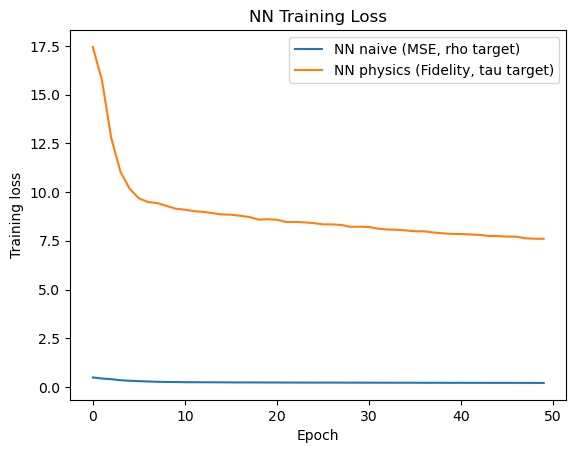

In [8]:
plt.figure()
plt.plot(outputs["nn_naive_history"]["loss"], label="NN naive (MSE, rho target)")
plt.plot(outputs["nn_phys_history"]["loss"], label="NN physics (Fidelity, tau target)")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("NN Training Loss")
plt.legend()
plt.show()

In [17]:
# Compute fidelities

true_rhos = data_test["rhos"]

def fidelities_vs_truth(pred_rhos):
    return np.array([qst.fidelity(true_rhos[k], pred_rhos[k]) for k in range(len(true_rhos))])

F_stokes = fidelities_vs_truth(outputs["stokes_rhos"])
F_naive  = fidelities_vs_truth(outputs["nn_naive_rhos"])
F_phys   = fidelities_vs_truth(outputs["nn_phys_rhos"])

KeyError: 'nn_naive_rhos'

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/fx/lnm0r8px7dl3hm8pdd5ryl4w0000gn/T/ipykernel_9047/2964637264.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.hist(F_stokes, bins=30, alpha=0.6, label=f"Stokes ($\mu$: {F_stokes.mean():.3f}, $\sigma$: {F_stokes.std():.3f})")
/var/folders/fx/lnm0r8px7dl3hm8pdd5ryl4w0000gn/T/ipykernel_9047/2964637264.py:2: SyntaxWarning: invalid escape sequence '\s'
  plt.hist(F_stokes, bins=30,

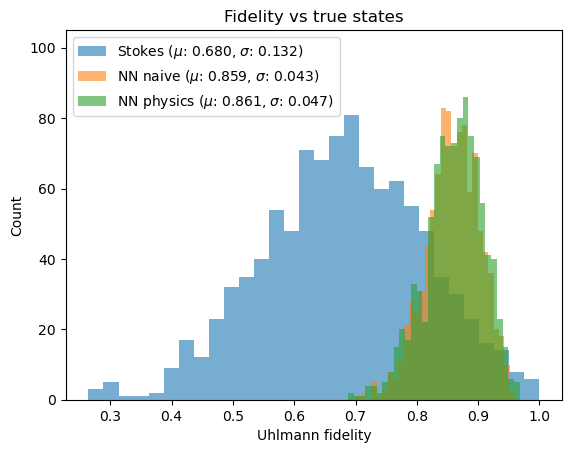

Mean fidelities:
  Stokes: 0.679666173004491 std: 0.13198200806341356
  Naive : 0.8585019586134713 std: 0.04328123914381102
  Phys  : 0.8607382960984716 std: 0.046657084583424144


In [24]:
plt.figure()
plt.hist(F_stokes, bins=30, alpha=0.6, label=f"Stokes ($\mu$: {F_stokes.mean():.3f}, $\sigma$: {F_stokes.std():.3f})")
plt.hist(F_naive,  bins=30, alpha=0.6, label=f"NN naive ($\mu$: {F_naive.mean():.3f}, $\sigma$: {F_naive.std():.3f})")
plt.hist(F_phys,   bins=30, alpha=0.6, label=f"NN physics ($\mu$: {F_phys.mean():.3f}, $\sigma$: {F_phys.std():.3f})")

plt.ylim(0,105)

plt.xlabel("Uhlmann fidelity")
plt.ylabel("Count")
plt.title("Fidelity vs true states")
plt.legend(loc='upper left')
plt.show()


print("Mean fidelities:")
print("  Stokes:", F_stokes.mean(), "std:", F_stokes.std())
print("  Naive :", F_naive.mean(),  "std:", F_naive.std())
print("  Phys  :", F_phys.mean(),   "std:", F_phys.std())